Author: Daniel Wilkinson

Date: 16 June 2026

# Preliminary EDA

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import json
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

# Consistent colour palette across all notebooks
COLORS = {
    'European hornet': '#E07B39',   # orange
    'Asian hornet':    '#3A6EA5',   # blue
    'missing':         '#BDBDBD',   # grey
    'accent':          '#2ECC71',   # green
}

DATA_DIR = Path(r'C:\Users\danie\PycharmProjects\nabu-asian-hornet-project-research\data')
print('Setup complete ✓')
print('Data directory:', DATA_DIR.resolve())
NOTEBOOK_DIR = Path(r'C:\Users\danie\PycharmProjects\nabu-asian-hornet-project-research\notebooks')
print("Notebook directory:", NOTEBOOK_DIR.resolve())

Setup complete ✓
Data directory: C:\Users\danie\PycharmProjects\nabu-asian-hornet-project-research\data
Notebook directory: C:\Users\danie\PycharmProjects\nabu-asian-hornet-project-research\notebooks


In [19]:
df_asian = pd.read_csv(DATA_DIR / 'asian_hornet_DE.csv')
df_european = pd.read_csv(DATA_DIR / 'european_hornet_DE.csv')

print(df_asian.columns.tolist())
print(df_european.columns.tolist())

# Identify columns common to both datasets
common_cols = df_asian.columns.intersection(df_european.columns)
print(f"Common columns: {len(common_cols)}")

# Columns exclusive to European hornet dataset
only_european = df_european.columns.difference(df_asian.columns)
print(f"Only in European hornet: {len(only_european)}")
print(only_european.tolist())

# Columns exclusive to Asian hornet dataset
only_asian = df_asian.columns.difference(df_european.columns)
print(f"Only in Asian hornet: {len(only_asian)}")
print(only_asian.tolist())

# Recommended core columns for comparative analysis
core_cols = [
    "species", "decimalLatitude", "decimalLongitude",
    "year", "month", "stateProvince", "basisOfRecord", "eventDate"
]

# Filter both datasets to core columns only
df_asian_core = df_asian[core_cols]
df_european_core = df_european[core_cols]

print(f"\nAsian hornet core shape:    {df_asian_core.shape}")
print(f"European hornet core shape: {df_european_core.shape}")

['key', 'datasetKey', 'publishingOrgKey', 'installationKey', 'hostingOrganizationKey', 'publishingCountry', 'protocol', 'lastCrawled', 'lastParsed', 'crawlId', 'extensions', 'basisOfRecord', 'occurrenceStatus', 'classifications', 'taxonKey', 'kingdomKey', 'phylumKey', 'classKey', 'orderKey', 'familyKey', 'genusKey', 'speciesKey', 'acceptedTaxonKey', 'scientificName', 'scientificNameAuthorship', 'acceptedScientificName', 'kingdom', 'phylum', 'order', 'family', 'genus', 'species', 'genericName', 'specificEpithet', 'infraspecificEpithet', 'taxonRank', 'taxonomicStatus', 'decimalLatitude', 'decimalLongitude', 'coordinateUncertaintyInMeters', 'continent', 'gadm', 'year', 'month', 'day', 'eventDate', 'startDayOfYear', 'endDayOfYear', 'issues', 'lastInterpreted', 'license', 'isSequenced', 'identifiers', 'media', 'facts', 'relations', 'isInCluster', 'datasetID', 'recordedBy', 'identifiedBy', 'dnaSequenceID', 'nucleotideSequence', 'geodeticDatum', 'class', 'countryCode', 'recordedByIDs', 'ident

In [20]:
FILES = {
    'European hornet': DATA_DIR / 'european_hornet_DE.csv',
    'Asian hornet':    DATA_DIR / 'asian_hornet_DE.csv',
}

# Verify files exist before loading
for label, path in FILES.items():
    exists  = path.exists()
    size_mb = path.stat().st_size / 1e6 if exists else 0
    status  = f'✅  {size_mb:.1f} MB' if exists else '❌  not found — run download_gbif.py first'
    print(f'  {label:<20}: {status}')

  European hornet     : ✅  259.6 MB
  Asian hornet        : ✅  76.8 MB


In [21]:
# Load both files and tag with species label
frames = []
for label, path in FILES.items():
    if not path.exists():
        print(f'Skipping {label} — file not found')
        continue
    tmp = pd.read_csv(path, low_memory=False)
    tmp['species_label'] = label
    frames.append(tmp)
    print(f'  {label}: {len(tmp):,} rows × {tmp.shape[1]} columns')

assert frames, 'No data loaded — check that data/ directory contains the CSV files'

df = pd.concat(frames, ignore_index=True)
print(f'\nCombined: {len(df):,} rows × {df.shape[1]} columns')

  European hornet: 61,356 rows × 156 columns
  Asian hornet: 17,917 rows × 125 columns

Combined: 79,273 rows × 161 columns


In [22]:
col_info = pd.DataFrame({
    'dtype':      df.dtypes,
    'non_null_n': df.notna().sum(),
    'null_pct':   (df.isna().mean() * 100).round(1),
    'n_unique':   df.nunique(),
    'sample':     df.iloc[0],
}).sort_values('null_pct')

print(f'Total columns            : {len(col_info)}')
print(f'Columns with >50% missing: {(col_info.null_pct > 50).sum()}')
print(f'Columns with >90% missing: {(col_info.null_pct > 90).sum()}')
print(f'Fully complete columns   : {(col_info.null_pct == 0).sum()}')
print()
col_info

Total columns            : 161
Columns with >50% missing: 84
Columns with >90% missing: 69
Fully complete columns   : 61



,dtype,non_null_n,null_pct,n_unique,sample
key,int64,79273,0.0000,79273,5014986938
datasetKey,str,79273,0.0000,153,6ac3f774-d9fb-4796-b3e9-92bf6c81c084
publishingOrgKey,str,79273,0.0000,22,bb646dff-a905-4403-a49b-6d378c2cf0d9
installationKey,str,79273,0.0000,21,36cae45c-1983-48be-9cf9-0672c4a60612
hostingOrganizationKey,str,79273,0.0000,20,bb646dff-a905-4403-a49b-6d378c2cf0d9
...,...,...,...,...,...
http://unknown.org/language,str,4,100.0000,1,NaN
http://unknown.org/id_threshold_skip,object,4,100.0000,1,NaN
http://unknown.org/modified,str,4,100.0000,2,NaN
originalNameUsage,str,4,100.0000,1,NaN


In [23]:
# Columns with zero missing — our most reliable fields
complete_cols = col_info[col_info['null_pct'] == 0].index.tolist()
print('Complete columns (0% missing):')
print(complete_cols)

Complete columns (0% missing):
['key', 'datasetKey', 'publishingOrgKey', 'installationKey', 'hostingOrganizationKey', 'publishingCountry', 'protocol', 'lastCrawled', 'lastParsed', 'crawlId', 'extensions', 'basisOfRecord', 'occurrenceStatus', 'classifications', 'taxonKey', 'kingdomKey', 'phylumKey', 'classKey', 'orderKey', 'familyKey', 'genusKey', 'speciesKey', 'acceptedTaxonKey', 'scientificName', 'scientificNameAuthorship', 'acceptedScientificName', 'kingdom', 'phylum', 'order', 'family', 'genus', 'species', 'genericName', 'specificEpithet', 'taxonRank', 'taxonomicStatus', 'continent', 'issues', 'year', 'gadm', 'eventDate', 'relations', 'media', 'facts', 'identifiers', 'isSequenced', 'license', 'lastInterpreted', 'recordedByIDs', 'dnaSequenceID', 'nucleotideSequence', 'class', 'countryCode', 'isInCluster', 'gbifRegion', 'identifiedByIDs', 'publishedByGbifRegion', 'country', 'gbifID', 'http://unknown.org/crawl_attempt', 'species_label']


In [24]:
print('── species field ────────────────────────────────────────')
if 'species' in df.columns:
    print(df['species'].value_counts(dropna=False).to_string())

print('\n── acceptedScientificName / verbatimScientificName ──────')
for col in ['acceptedScientificName', 'verbatimScientificName', 'scientificName']:
    if col in df.columns:
        print(f'{col}:')
        print(df[col].value_counts(dropna=False).head(8).to_string())
        print()

print('── taxonKey / speciesKey ────────────────────────────────')
for col in ['speciesKey', 'taxonKey', 'acceptedTaxonKey']:
    if col in df.columns:
        print(f'{col}: {df[col].value_counts(dropna=False).head(5).to_dict()}')

── species field ────────────────────────────────────────
species
Vespa crabro      61356
Vespa velutina    17917

── acceptedScientificName / verbatimScientificName ──────
acceptedScientificName:
acceptedScientificName
Vespa crabro Linnaeus                       60724
Vespa velutina Lepeletier, 1836             16726
Vespa velutina nigrithorax Buysson, 1905     1191
Vespa crabro germana Christ, 1791             595
BOLD:ABA8441                                   29
Vespa crabro crabro                             8

scientificName:
scientificName
Vespa crabro Linnaeus                       60724
Vespa velutina Lepeletier, 1836             16726
Vespa velutina nigrithorax Buysson, 1905     1191
Vespa crabro germana Christ, 1791             595
BOLD:ABA8441                                   29
Vespa crabro crabro                             8

── taxonKey / speciesKey ────────────────────────────────
speciesKey: {1311527: 61356, 1311477: 17917}
taxonKey: {1311527: 60724, 1311477: 16726, 6

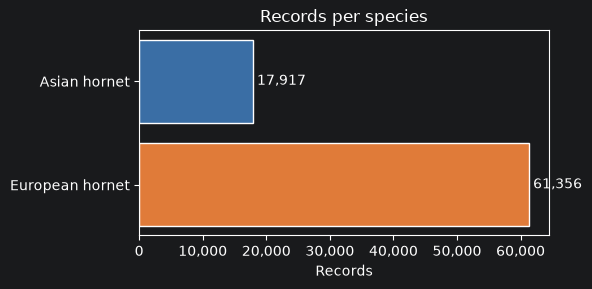

In [25]:
# Record counts per species_label
counts = df['species_label'].value_counts()

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(
    counts.index,
    counts.values,
    color=[COLORS[k] for k in counts.index],
    edgecolor='white'
)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
ax.set_xlabel('Records')
ax.set_title('Records per species')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [26]:
# Temporal Coverage

print('── year ──────────────────────────────────────────────────')
if 'year' in df.columns:
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    print(df['year'].describe())
    print(f'\nMissing: {df["year"].isna().sum():,} ({df["year"].isna().mean()*100:.1f}%)')

print('\n── month ─────────────────────────────────────────────────')
if 'month' in df.columns:
    df['month'] = pd.to_numeric(df['month'], errors='coerce')
    print(f'Missing: {df["month"].isna().sum():,} ({df["month"].isna().mean()*100:.1f}%)')
    invalid_month = df[~df['month'].between(1, 12) & df['month'].notna()]
    if len(invalid_month):
        print(f'⚠️  Invalid month values: {invalid_month["month"].unique()}')
    else:
        print('Month values all in [1–12] ✓')

if 'eventDate' in df.columns:
    df['eventDate'] = pd.to_datetime(df['eventDate'], errors='coerce')
    miss_ed = df['eventDate'].isna().sum()
    print(f'\neventDate missing: {miss_ed:,} ({miss_ed/len(df)*100:.1f}%)')

── year ──────────────────────────────────────────────────
count   79273.0000
mean     2022.3415
std         3.6043
min      2000.0000
25%      2021.0000
50%      2024.0000
75%      2025.0000
max      2025.0000
Name: year, dtype: float64

Missing: 0 (0.0%)

── month ─────────────────────────────────────────────────
Missing: 144 (0.2%)
Month values all in [1–12] ✓

eventDate missing: 34,409 (43.4%)


In [27]:
# Check for truncated years
# Check for truncated years (near MAX_PER_YEAR = 20,000)
yearly_per_species = (
    df.groupby(['year', 'species_label'])
    .size()
    .reset_index(name='n_loaded')
    .sort_values(['species_label', 'year'])
)

truncated = yearly_per_species[yearly_per_species['n_loaded'] >= 19_000]
if len(truncated):
    print('⚠️  TRUNCATED years (≥ 19,000 records — near MAX_PER_YEAR cap):')
    print(truncated.to_string(index=False))
    print('\nThese years are underrepresented. Note when interpreting trends.')
else:
    print('✅  No truncated years detected')

print(f'\nYears with zero records per species:')
all_years = set(range(2000, 2026))
for label in df['species_label'].unique():
    years_with_data = set(yearly_per_species[yearly_per_species['species_label'] == label]['year'].dropna().astype(int))
    missing_years   = sorted(all_years - years_with_data)
    print(f'  {label}: {missing_years if missing_years else "none"}')

✅  No truncated years detected

Years with zero records per species:
  European hornet: none
  Asian hornet: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013]


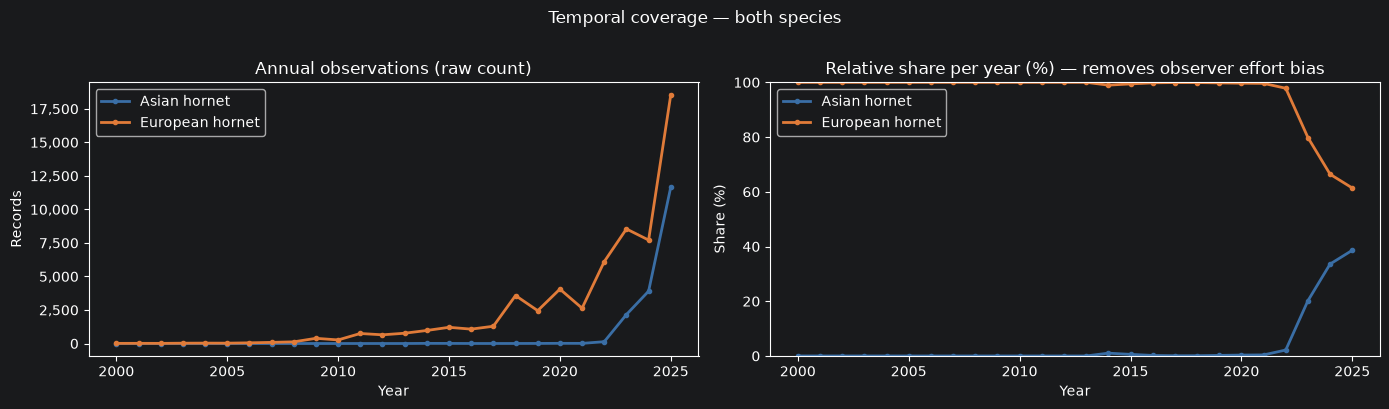

Note: rising Asian hornet share is the key signal for RQ1 (displacement).
Raw count growth partly reflects more observers over time, not just more hornets.


In [28]:
# Annual observations — raw count + relative share
yearly = (
    df.groupby(['year', 'species_label'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for col in yearly.columns:
    axes[0].plot(yearly.index, yearly[col], color=COLORS[col],
                 label=col, linewidth=2, marker='o', markersize=3)
axes[0].set_title('Annual observations (raw count)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Records')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Relative share — removes absolute observer-effort growth
yearly_norm = yearly.div(yearly.sum(axis=1).replace(0, np.nan), axis=0) * 100
for col in yearly_norm.columns:
    axes[1].plot(yearly_norm.index, yearly_norm[col], color=COLORS[col],
                 label=col, linewidth=2, marker='o', markersize=3)
axes[1].set_title('Relative share per year (%) — removes observer effort bias')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Share (%)')
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.suptitle('Temporal coverage — both species', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('Note: rising Asian hornet share is the key signal for RQ1 (displacement).')
print('Raw count growth partly reflects more observers over time, not just more hornets.')

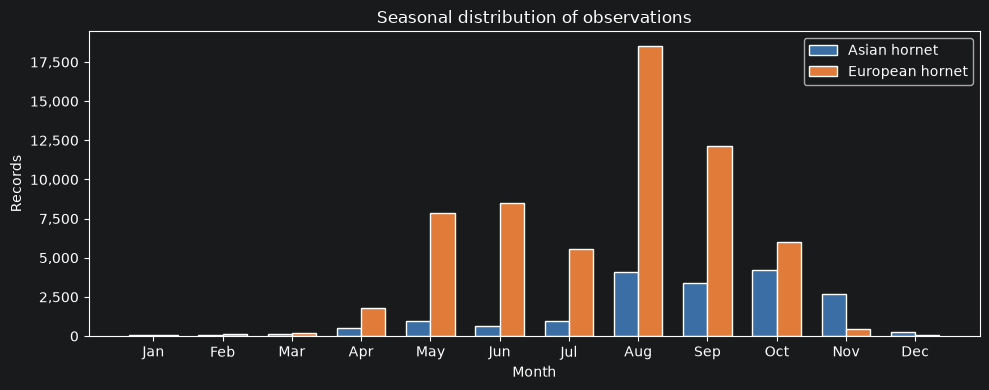

Expected peak: Jul–Sep.
Winter gap (Nov–Mar) is biological — colonies die off, only queens survive.


In [29]:
# Seasonal Distribution

# Seasonal distribution
if 'month' in df.columns:
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']
    monthly = (
        df.groupby(['month', 'species_label'])
        .size()
        .unstack(fill_value=0)
        .reindex(range(1, 13), fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(1, 13)
    w = 0.35
    for i, col in enumerate(monthly.columns):
        offset = (i - (len(monthly.columns) - 1) / 2) * w
        ax.bar(x + offset, monthly[col], width=w,
               color=COLORS[col], label=col, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(month_labels)
    ax.set_xlabel('Month')
    ax.set_ylabel('Records')
    ax.set_title('Seasonal distribution of observations')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()

    print('Expected peak: Jul–Sep.')
    print('Winter gap (Nov–Mar) is biological — colonies die off, only queens survive.')

In [30]:
# Spatial Coverage

print('── Coordinate fields ────────────────────────────────────')
for col in ['decimalLatitude', 'decimalLongitude', 'coordinateUncertaintyInMeters']:
    if col not in df.columns:
        print(f'{col}: NOT FOUND')
        continue
    df[col] = pd.to_numeric(df[col], errors='coerce')
    miss = df[col].isna().sum()
    print(f'\n{col}:')
    print(f'  Missing: {miss:,} ({miss/len(df)*100:.1f}%)')
    valid = df[col].dropna()
    print(f'  Min: {valid.min():.4f}   Max: {valid.max():.4f}')
    if 'Uncertainty' in col:
        print(f'  Median: {valid.median():.0f} m   95th pct: {valid.quantile(0.95):.0f} m')

── Coordinate fields ────────────────────────────────────

decimalLatitude:
  Missing: 170 (0.2%)
  Min: 0.0000   Max: 55.0450

decimalLongitude:
  Missing: 170 (0.2%)
  Min: 0.0000   Max: 15.0397

coordinateUncertaintyInMeters:
  Missing: 7,158 (9.0%)
  Min: 1.0000   Max: 10282623.0000
  Median: 25 m   95th pct: 250 m


In [31]:
print('── Coordinate quality checks ────────────────────────────')

# (0, 0) — known GBIF placeholder issue
zero_mask = (df['decimalLatitude'] == 0) & (df['decimalLongitude'] == 0)
print(f'Exact (0, 0) records        : {zero_mask.sum()} ← likely missing coords, exclude')

# Records outside Germany bounding box (download used country="DE")
de_bbox = dict(lat_min=47.2, lat_max=55.1, lon_min=5.8, lon_max=15.1)
df_geo  = df.dropna(subset=['decimalLatitude', 'decimalLongitude'])
outside = df_geo[
    (df_geo['decimalLatitude']  < de_bbox['lat_min']) |
    (df_geo['decimalLatitude']  > de_bbox['lat_max']) |
    (df_geo['decimalLongitude'] < de_bbox['lon_min']) |
    (df_geo['decimalLongitude'] > de_bbox['lon_max'])
]
print(f'Outside DE bounding box     : {len(outside)}')
if len(outside) > 0:
    cols = [c for c in ['species_label','decimalLatitude','decimalLongitude',
                        'countryCode','stateProvince'] if c in outside.columns]
    print(outside[cols].head(10).to_string())

# hasGeospatialIssues
if 'hasGeospatialIssues' in df.columns:
    geo_iss = df['hasGeospatialIssues'].sum()
    print(f'hasGeospatialIssues = True  : {geo_iss:,} ({geo_iss/len(df)*100:.1f}%)')

── Coordinate quality checks ────────────────────────────
Exact (0, 0) records        : 1 ← likely missing coords, exclude
Outside DE bounding box     : 4
         species_label  decimalLatitude  decimalLongitude countryCode stateProvince
35000  European hornet          42.0955           12.1895          DE           NaN
35001  European hornet          42.0955           12.1895          DE           NaN
35006  European hornet          42.0955           12.1895          DE           NaN
75224     Asian hornet           0.0000            0.0000          DE           NaN


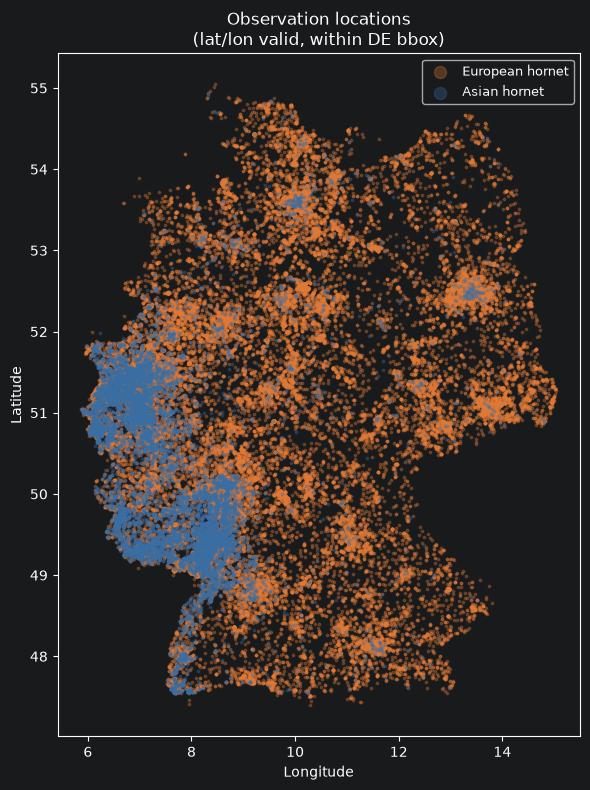

Points shown: 79,099


In [32]:
# Sanity-check scatter plot — points should land inside Germany
df_plot = df.dropna(subset=['decimalLatitude', 'decimalLongitude'])
df_plot = df_plot[
    df_plot['decimalLatitude'].between(47.0, 56.0) &
    df_plot['decimalLongitude'].between(5.0, 16.0)
]

fig, ax = plt.subplots(figsize=(6, 8))
for label in df_plot['species_label'].unique():
    sub = df_plot[df_plot['species_label'] == label]
    ax.scatter(sub['decimalLongitude'], sub['decimalLatitude'],
               c=COLORS[label], label=label, alpha=0.3, s=3)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Observation locations\n(lat/lon valid, within DE bbox)')
ax.legend(markerscale=5, fontsize=9)
plt.tight_layout()
plt.show()

print(f'Points shown: {len(df_plot):,}')

In [33]:
# Federal state (Bundesland) coverage
if 'stateProvince' in df.columns:
    print('── stateProvince ────────────────────────────────────────')
    miss = df['stateProvince'].isna().sum()
    print(f'Missing  : {miss:,} ({miss/len(df)*100:.1f}%)')
    print(f'Unique   : {df["stateProvince"].nunique()}')
    print()
    print('Value counts — check for inconsistent naming (Umlauts, abbreviations):')
    print(df['stateProvince'].value_counts(dropna=False).head(25).to_string())

── stateProvince ────────────────────────────────────────
Missing  : 51,659 (65.2%)
Unique   : 28

Value counts — check for inconsistent naming (Umlauts, abbreviations):
stateProvince
NaN                       51659
Nordrhein-Westfalen        8635
Niedersachsen              3277
Bayern                     2726
Baden-Württemberg          2613
Hessen                     2243
Rheinland-Pfalz            1809
Schleswig-Holstein         1409
Sachsen                    1125
Brandenburg                 845
Berlin                      588
Mecklenburg-Vorpommern      520
Sachsen-Anhalt              490
Hamburg                     413
Saarland                    346
Thüringen                   335
Bremen                      142
Rhineland-Palatinate         53
Spessart                     12
Grevenmacher                  9
Limburg                       8
Bavaria                       4
Steigerwald                   3
Saxony                        2
Oberösterreich                2


In [34]:
# Taking confirmed pictures into account

print('── basisOfRecord ────────────────────────────────────────')
if 'basisOfRecord' in df.columns:
    bor = df['basisOfRecord'].value_counts(dropna=False)
    print(bor.to_string())
    print(f'\nHUMAN_OBSERVATION share: {(df["basisOfRecord"]=="HUMAN_OBSERVATION").mean()*100:.1f}%')

── basisOfRecord ────────────────────────────────────────
basisOfRecord
HUMAN_OBSERVATION      79164
MACHINE_OBSERVATION       48
MATERIAL_SAMPLE           29
PRESERVED_SPECIMEN        28
OBSERVATION                2
OCCURRENCE                 2

HUMAN_OBSERVATION share: 99.9%


In [35]:
print('── mediaType ────────────────────────────────────────────')
if 'mediaType' in df.columns:
    print(df['mediaType'].value_counts(dropna=False).to_string())
    photo_n   = (df['mediaType'] == 'StillImage').sum()
    photo_pct = photo_n / len(df) * 100
    print(f'\nPhoto-verified (StillImage): {photo_n:,} ({photo_pct:.1f}% of total)')
    print(f'→ Applying photo filter retains {photo_pct:.1f}% of records')
    print()

    # Photo rate per species
    photo_rate = (
        df.assign(has_photo=(df['mediaType'] == 'StillImage'))
        .groupby('species_label')['has_photo']
        .agg(total='count', with_photo='sum')
    )
    photo_rate['photo_pct'] = (photo_rate['with_photo'] / photo_rate['total'] * 100).round(1)
    print('Photo rate by species:')
    print(photo_rate.to_string())
    print()
    print('Decision for cleaning step: keep photo filter as default, but run')
    print('sensitivity analysis to check whether it introduces spatial bias.')
else:
    print('mediaType column not found.')
    print('Check alternative fields: media, multimedia, associatedMedia')
    for col in ['media', 'multimedia', 'associatedMedia']:
        if col in df.columns:
            print(f'  Found: {col} — unique values: {df[col].nunique()}')

── mediaType ────────────────────────────────────────────
mediaType column not found.
Check alternative fields: media, multimedia, associatedMedia
  Found: media — unique values: 33619


In [36]:
for col in ['datasetName', 'institutionCode', 'datasetKey']:
    if col in df.columns:
        print(f'── {col} ──────────────────────────────')
        print(df[col].value_counts(dropna=False).head(12).to_string())
        print()

# NABU|naturgucker share
if 'datasetName' in df.columns:
    nabu_mask = df['datasetName'].str.contains('naturgucker|NABU', case=False, na=False)
    nabu_n    = nabu_mask.sum()
    print(f'NABU|naturgucker records: {nabu_n:,} ({nabu_n/len(df)*100:.1f}%)')
    print('(Updated weekly to GBIF per Theresa Seidel — primary source for live dashboard)')

── datasetName ──────────────────────────────
datasetName
NaN                                                       72635
iNaturalist research-grade observations                    6625
https://doi.org/10.15468/umefbe                               9
General recording - MNHNL Data Portal                         2
Données ponctuelles                                           1
izeltlabuak.hu observations validated to species level        1

── institutionCode ──────────────────────────────
institutionCode
NABU|naturgucker                                  42377
NaN                                               20972
https://artenfinder.net                            7788
iNaturalist                                        6625
NABU Sachsen AK Entomologie                        1291
GEO                                                 132
Anymals.org                                          20
Zoologisches Forschungsmuseum Alexander Koenig       20
NMOK                                       

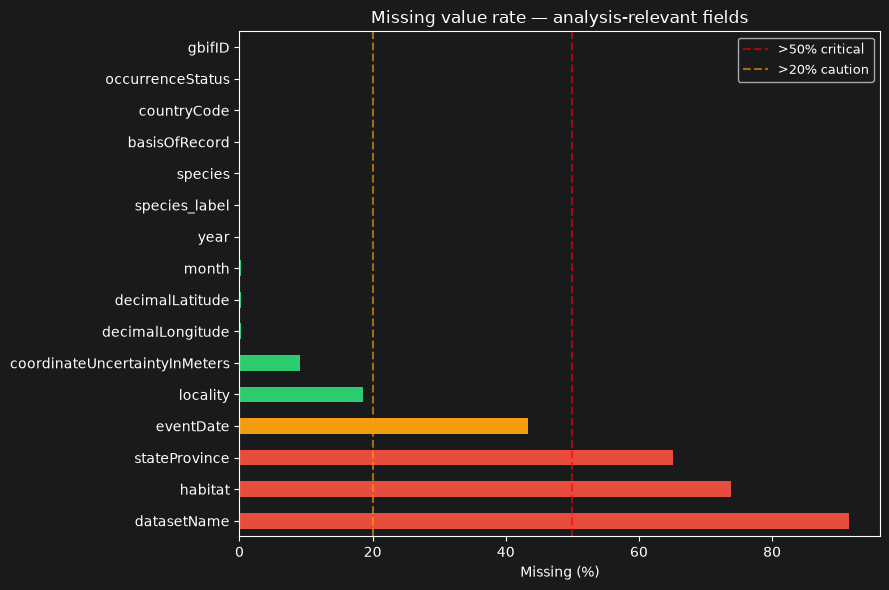

Fields missing in >50% of records:
datasetName     91.6000
habitat         73.9000
stateProvince   65.2000


In [37]:
rq_fields = [
    'species', 'species_label',
    'decimalLatitude', 'decimalLongitude', 'coordinateUncertaintyInMeters',
    'hasGeospatialIssues', 'hasCoordinate',
    'year', 'month', 'eventDate',
    'stateProvince', 'countryCode',
    'basisOfRecord', 'mediaType',
    'locality', 'habitat',
    'occurrenceStatus', 'datasetName', 'gbifID',
]
present = [c for c in rq_fields if c in df.columns]

missing_pct = df[present].isna().mean().mul(100).sort_values(ascending=False)

bar_colors = ['#E74C3C' if v > 50 else '#F39C12' if v > 20 else '#2ECC71'
              for v in missing_pct]

fig, ax = plt.subplots(figsize=(9, 6))
missing_pct.plot(kind='barh', ax=ax, color=bar_colors)
ax.axvline(50, color='red',    linestyle='--', alpha=0.6, label='>50% critical')
ax.axvline(20, color='orange', linestyle='--', alpha=0.6, label='>20% caution')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing value rate — analysis-relevant fields')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Fields missing in >50% of records:')
print(missing_pct[missing_pct > 50].round(1).to_string())

In [38]:
RQ_MAP = {
    'RQ1 — Range competition V.velutina vs V.crabro': {
        'gbif':     ['species', 'decimalLatitude', 'decimalLongitude', 'year', 'stateProvince'],
        'external': [],
        'note':     'Fully covered by GBIF. Key analysis: spatial overlap per year.',
    },
    'RQ2 — V.crabro distribution in Germany': {
        'gbif':     ['decimalLatitude', 'decimalLongitude', 'stateProvince',
                     'coordinateUncertaintyInMeters'],
        'external': [],
        'note':     'Fully covered. Apply coordinateUncertaintyInMeters < 10,000 m filter.',
    },
    'RQ3 — Habitat type correlation': {
        'gbif':     ['decimalLatitude', 'decimalLongitude'],
        'external': ['CORINE Land Cover 2018', 'OpenStreetMap land use polygons'],
        'note':     'GBIF "habitat" field nearly empty. Requires spatial join with CORINE.',
    },
    'RQ4 — Protected areas (Natura 2000)': {
        'gbif':     ['decimalLatitude', 'decimalLongitude'],
        'external': ['Natura 2000 shapefile (EEA)', 'WDPA — World Database on Protected Areas'],
        'note':     'No protected area field in GBIF. Spatial join required.',
    },
    'RQ5 — Synanthropic behaviour / urban proximity': {
        'gbif':     ['decimalLatitude', 'decimalLongitude'],
        'external': ['GHS-POP population density raster', 'OSM urban area polygons'],
        'note':     'Urban proximity requires external population / land-use layers.',
    },
    'RQ6 — Weather / seasonality (lower priority)': {
        'gbif':     ['year', 'month', 'decimalLatitude', 'decimalLongitude'],
        'external': ['ERA5 climate reanalysis (Copernicus)', 'DWD open data'],
        'note':     'Lower priority per Theresa Seidel. GBIF covers temporal dimension; climate is external.',
    },
}

for rq, info in RQ_MAP.items():
    gbif_ok   = [f for f in info['gbif'] if f in df.columns]
    gbif_miss = [f for f in info['gbif'] if f not in df.columns]
    if gbif_miss:
        icon = '❌'
    elif info['external']:
        icon = '⚠️ '
    else:
        icon = '✅'
    print(f'{icon}  {rq}')
    print(f'     GBIF available  : {gbif_ok}')
    if gbif_miss:
        print(f'     GBIF missing    : {gbif_miss}')
    if info['external']:
        print(f'     External needed : {info["external"]}')
    print(f'     Note            : {info["note"]}')
    print()

✅  RQ1 — Range competition V.velutina vs V.crabro
     GBIF available  : ['species', 'decimalLatitude', 'decimalLongitude', 'year', 'stateProvince']
     Note            : Fully covered by GBIF. Key analysis: spatial overlap per year.

✅  RQ2 — V.crabro distribution in Germany
     GBIF available  : ['decimalLatitude', 'decimalLongitude', 'stateProvince', 'coordinateUncertaintyInMeters']
     Note            : Fully covered. Apply coordinateUncertaintyInMeters < 10,000 m filter.

⚠️   RQ3 — Habitat type correlation
     GBIF available  : ['decimalLatitude', 'decimalLongitude']
     External needed : ['CORINE Land Cover 2018', 'OpenStreetMap land use polygons']
     Note            : GBIF "habitat" field nearly empty. Requires spatial join with CORINE.

⚠️   RQ4 — Protected areas (Natura 2000)
     GBIF available  : ['decimalLatitude', 'decimalLongitude']
     External needed : ['Natura 2000 shapefile (EEA)', 'WDPA — World Database on Protected Areas']
     Note            : No protecte

In [39]:
summary = {
    'total_records':      int(len(df)),
    'european_hornet':    int((df['species_label'] == 'European hornet').sum()),
    'asian_hornet':       int((df['species_label'] == 'Asian hornet').sum()),
    'year_range':         f"{int(df['year'].min())}–{int(df['year'].max())}" if 'year' in df.columns else 'N/A',
    'n_columns':          int(df.shape[1]),
    'pct_with_coords':    round(
                            df[['decimalLatitude','decimalLongitude']]
                            .notna().all(axis=1).mean() * 100, 1),
    'pct_photo_verified': round((df.get('mediaType') == 'StillImage').mean() * 100, 1)
                          if 'mediaType' in df.columns else 'field_absent',
    'zero_coord_records': int(((df['decimalLatitude'] == 0) & (df['decimalLongitude'] == 0)).sum()),
    'geospatial_issues':  int(df['hasGeospatialIssues'].sum())
                          if 'hasGeospatialIssues' in df.columns else 'field_absent',
}

print('=' * 60)
print('  DATA UNDERSTANDING SUMMARY')
print('=' * 60)
for k, v in summary.items():
    print(f'  {k:<28}: {v}')

Path('./data').mkdir(exist_ok=True)
with open('./data/01_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('\nSaved: ./data/01_summary.json')

  DATA UNDERSTANDING SUMMARY
  total_records               : 79273
  european_hornet             : 61356
  asian_hornet                : 17917
  year_range                  : 2000–2025
  n_columns                   : 161
  pct_with_coords             : 99.8
  pct_photo_verified          : field_absent
  zero_coord_records          : 1
  geospatial_issues           : field_absent

Saved: ./data/01_summary.json


In [40]:
print('CLEANING CHECKLIST — carry into Notebook 02:\n')
checklist = [
    ('Deduplication',      'Drop duplicate gbifID values'),
    ('Coordinate filter',  'Remove records where hasGeospatialIssues = True'),
    ('Coordinate filter',  'Remove exact (0, 0) coordinate records'),
    ('Coordinate filter',  'Apply coordinateUncertaintyInMeters < 10,000 m threshold'),
    ('Photo filter',       'Keep mediaType = StillImage as default (NABU recommendation)'),
    ('Photo filter',       'Run sensitivity: how does photo filter change spatial distribution?'),
    ('Year filter',        'Keep year in 2000–2025 (download range)'),
    ('Truncation flag',    'Flag years near 20,000 records as potentially underrepresented'),
    ('Bundesland names',   'Standardise stateProvince (Umlauts, short forms, None → Unknown)'),
    ('Date fallback',      'Derive year/month from eventDate where direct fields are NaN'),
    ('External joins',     'CORINE (RQ3) · Natura 2000 (RQ4) · GHS-POP (RQ5) — plan in NB 03+'),
]

for category, task in checklist:
    print(f'  [ ]  [{category}]  {task}')

CLEANING CHECKLIST — carry into Notebook 02:

  [ ]  [Deduplication]  Drop duplicate gbifID values
  [ ]  [Coordinate filter]  Remove records where hasGeospatialIssues = True
  [ ]  [Coordinate filter]  Remove exact (0, 0) coordinate records
  [ ]  [Coordinate filter]  Apply coordinateUncertaintyInMeters < 10,000 m threshold
  [ ]  [Photo filter]  Keep mediaType = StillImage as default (NABU recommendation)
  [ ]  [Photo filter]  Run sensitivity: how does photo filter change spatial distribution?
  [ ]  [Year filter]  Keep year in 2000–2025 (download range)
  [ ]  [Truncation flag]  Flag years near 20,000 records as potentially underrepresented
  [ ]  [Bundesland names]  Standardise stateProvince (Umlauts, short forms, None → Unknown)
  [ ]  [Date fallback]  Derive year/month from eventDate where direct fields are NaN
  [ ]  [External joins]  CORINE (RQ3) · Natura 2000 (RQ4) · GHS-POP (RQ5) — plan in NB 03+


In [41]:
# Знайти photo-related та issue-related колонки
photo_cols = [c for c in df.columns if any(x in c.lower()
              for x in ['media', 'photo', 'image', 'still', 'sound'])]
issue_cols = [c for c in df.columns if any(x in c.lower()
              for x in ['issue', 'geo', 'spatial', 'hascoord'])]

print("Photo cols:", photo_cols)
print("Issue cols:", issue_cols)

# Переглянути sample значення
for col in photo_cols + issue_cols:
    print(f"\n{col}:")
    print(df[col].dropna().head(3).tolist())

Photo cols: ['media']
Issue cols: ['issues', 'geodeticDatum', 'georeferenceSources', 'higherGeography', 'higherGeographyID', 'georeferencedBy', 'georeferencedDate']

media:
['[]', '[]', "[{'type': 'Sound', 'format': 'audio/mpeg', 'references': 'http://www.tierstimmenarchiv.de/webinterface/contents/showdetails.php?edit=-1&unique_id=TSA:Vespa_crabro_V_2087_5_1&autologin=true', 'license': 'http://creativecommons.org/licenses/by-nc-sa/4.0/', 'identifier': 'http://www.tierstimmenarchiv.de/recordings/Vespa_crabro_V2087_05_short.mp3'}]"]

issues:
["['COORDINATE_ROUNDED', 'GEODETIC_DATUM_ASSUMED_WGS84', 'CONTINENT_DERIVED_FROM_COORDINATES']", "['COORDINATE_ROUNDED', 'GEODETIC_DATUM_ASSUMED_WGS84', 'CONTINENT_DERIVED_FROM_COORDINATES']", "['GEODETIC_DATUM_ASSUMED_WGS84', 'CONTINENT_DERIVED_FROM_COORDINATES']"]

geodeticDatum:
['WGS84', 'WGS84', 'WGS84']

georeferenceSources:
['GPS', 'GPS']

higherGeography:
['Hochrheingebiet', 'Hochrheingebiet', 'Hochrheingebiet']

higherGeographyID:
['https://